<a href="https://colab.research.google.com/github/HarshvardhanJ/GDSC-AIML-26/blob/main/Quick_Doodle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Doodle Recognizer

Today we're training a **Convolutional Neural Network (CNN)** to recognize doodles, a smaller clone of Google's *Quick, Draw!* game.

By the end of this notebook, you'll be able to **draw your own doodle and watch the AI guess it, live.**

**The plan:**
1. Load doodle data (Google's Quick, Draw! dataset)
2. Build a small CNN with Keras
3. Train it
4. Test it
5. Draw your own doodle & get a live prediction

> Run each cell top to bottom with **Shift+Enter**. Read the comments to understand why the code is there and what is it doing.


## Step 0 — Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import urllib.parse
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("All libs imported")


TensorFlow version: 2.20.0
All set ✓


## Step 1 — Load the Doodles

We'll use 5 categories from the **Quick, Draw!** dataset — 50 million+ doodles drawn by real people,
released for free by Google. Each doodle is already a clean 28×28 grayscale image.

Feel free to swap in different categories — the full list is at
https://github.com/googlecreativelab/quickdraw-dataset


In [2]:
# Pick your categories! Change these for a different vibe.
CATEGORIES = ["cat", "star", "tree", "smiley face", "umbrella"]

DATA_DIR = "quickdraw_data"
os.makedirs(DATA_DIR, exist_ok=True)

BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

for cat in CATEGORIES:
    fname = os.path.join(DATA_DIR, f"{cat}.npy")
    if not os.path.exists(fname):
        url = BASE_URL + urllib.parse.quote(cat) + ".npy"
        print(f"Downloading {cat} ...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"{cat} already downloaded ✓")

print("\nAll categories ready ✓")



All categories ready ✓


In [3]:
# Load each category, keep a manageable number of samples per class so training stays fast,
# and build our (images, labels) dataset.

SAMPLES_PER_CLASS = 4000  # increase this later if you want a more accurate model

all_images = []
all_labels = []

for label_idx, cat in enumerate(CATEGORIES):
    data = np.load(os.path.join(DATA_DIR, f"{cat}.npy"))
    np.random.shuffle(data)
    data = data[:SAMPLES_PER_CLASS]
    all_images.append(data)
    all_labels.append(np.full(len(data), label_idx))
    print(f"{cat:12s}: {len(data)} samples loaded")

X = np.concatenate(all_images, axis=0)
y = np.concatenate(all_labels, axis=0)

# Each image arrives as a flat row of 784 numbers (0-255) -- reshape into a 28x28 grid
# and normalize pixel values to 0-1, which neural networks train on much more easily.
X = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print("\nDataset shape:", X.shape, "| Labels shape:", y.shape)


cat         : 4000 samples loaded
star        : 4000 samples loaded
tree        : 4000 samples loaded
smiley face : 4000 samples loaded
umbrella    : 4000 samples loaded

Dataset shape: (20000, 28, 28, 1) | Labels shape: (20000,)


In [4]:
# Shuffle everything together, then split into train and test sets.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 17000
Test samples: 3000


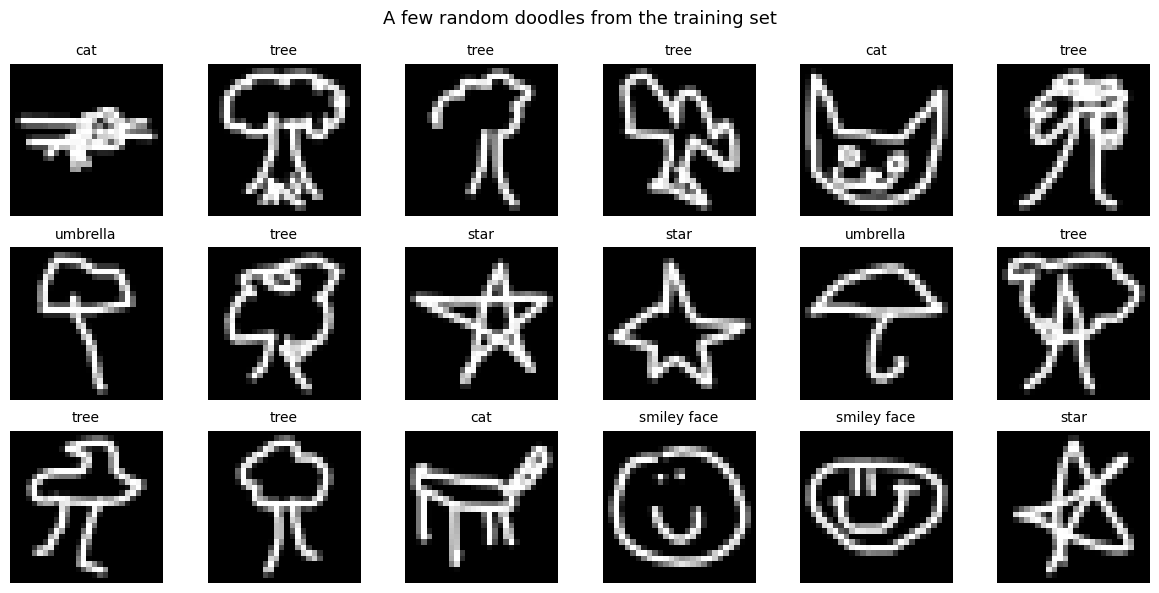

In [6]:
# Let's actually LOOK at what we're working with -- always a good habit before training anything.
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for ax in axes.flat:
    i = np.random.randint(0, len(X_train))
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(CATEGORIES[y_train[i]], fontsize=10)
    ax.axis("off")
plt.suptitle("A few random doodles from the training set", fontsize=13)
plt.tight_layout()
plt.show()


## Step 2 — Build the CNN

Remember the pipeline from the slides: **Conv → Pool → Conv → Pool → Flatten → Dense → Output**.

In Keras, that's about 10 lines. You don't write the convolution math yourself — you just describe
the pipeline and Keras builds it for you.


In [7]:
num_classes = len(CATEGORIES)

model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    # First conv block: learns simple patterns (edges, curves)
    layers.Conv2D(16, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    # Second conv block: combines simple patterns into more complex shapes
    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(pool_size=2),

    # Flatten the grid into a list, then let a couple of Dense layers make the final decision
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),  # randomly "mutes" some neurons during training -- helps avoid overfitting
    layers.Dense(num_classes, activation="softmax"),  # one probability per category
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,389 (220.27 KB)

 Trainable params: 56,389 (220.27 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3 — Train It

This is where "predict → compare → adjust → repeat" (the hot/cold game from the slides) actually happens,
thousands of times, automatically.


In [8]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",  # good default for multi-class classification
    metrics=["accuracy"],
)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=8,
    batch_size=128,
)


Epoch 1/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.7745 - loss: 0.6340 - val_accuracy: 0.8847 - val_loss: 0.3397
Epoch 2/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.8844 - loss: 0.3301 - val_accuracy: 0.9065 - val_loss: 0.2601
Epoch 3/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.9108 - loss: 0.2618 - val_accuracy: 0.9206 - val_loss: 0.2235
Epoch 4/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9235 - loss: 0.2253 - val_accuracy: 0.9294 - val_loss: 0.2076
Epoch 5/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.9320 - loss: 0.1963 - val_accuracy: 0.9329 - val_loss: 0.1943
Epoch 6/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9391 - loss: 0.1845 - val_accuracy: 0.9353 - val_loss: 0.1864
Epoch 7/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9446 - loss: 0.1669 - val_accuracy: 0.9429 - val_loss: 0.1798
Epoch 8/8
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9499 - loss: 0.1522 - val_accuracy: 

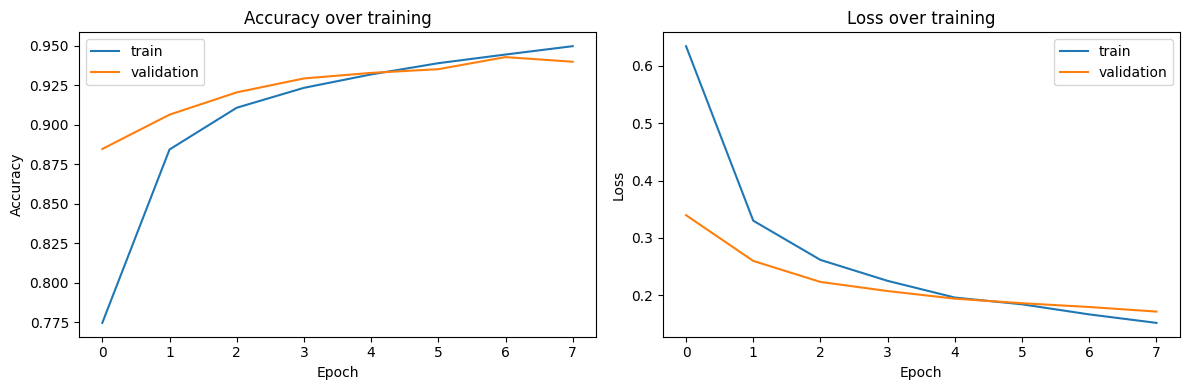

In [9]:
# Plot how accuracy and loss changed over training
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy over training")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="validation")
axes[1].set_title("Loss over training")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()


### 🧪 Exercise for attendees

1. Change `SAMPLES_PER_CLASS` to 1000 and retrain — how much does accuracy drop?
2. Change `epochs` to 3, then to 20 — where does it stop improving?
3. **Challenge:** add a third `Conv2D` + `MaxPooling2D` block. Does it help?

## Step 4 — Test It

Let's see how the model does on doodles it has **never seen before**.

In [10]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc*100:.1f}%")


Test accuracy: 94.1%


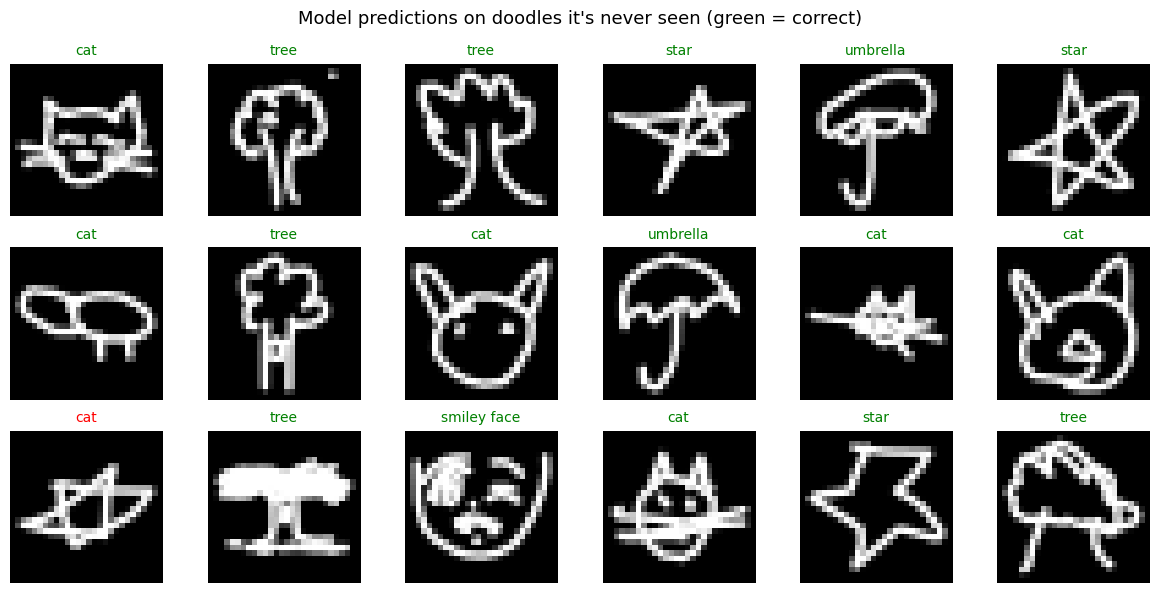

In [11]:
# Show a grid of test predictions -- green title = correct, red = wrong
fig, axes = plt.subplots(3, 6, figsize=(12, 6))
sample_idx = np.random.choice(len(X_test), size=18, replace=False)
preds = model.predict(X_test[sample_idx], verbose=0)

for ax, i, pred in zip(axes.flat, sample_idx, preds):
    guess = CATEGORIES[np.argmax(pred)]
    truth = CATEGORIES[y_test[i]]
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title(guess, color=("green" if guess == truth else "red"), fontsize=10)
    ax.axis("off")

plt.suptitle("Model predictions on doodles it's never seen (green = correct)", fontsize=13)
plt.tight_layout()
plt.show()


## Step 5 — Draw & Guess!

Now the fun part. Run the next cell, **draw a doodle of one of our 5 categories** with your mouse/trackpad, then run the cell after it to see the AI's guess.

> If the canvas doesn't work on your machine, skip to the **Bonus: upload a photo** cell below instead.

Draw above, then click Predict. The AI's guess will appear right under the canvas each time.


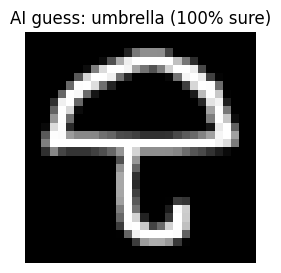

Confidence for every category:
  umbrella     100.0%
  tree           0.0%
  smiley face    0.0%
  cat            0.0%
  star           0.0%


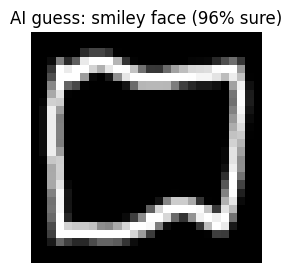

Confidence for every category:
  smiley face   95.7%
  cat            2.5%
  umbrella       1.2%
  tree           0.6%
  star           0.0%


In [18]:
from IPython.display import display, HTML
from google.colab import output
from base64 import b64decode
from PIL import Image, ImageOps
import io

CANVAS_HTML = """
<canvas id="canvas" width="280" height="280"
        style="border:3px solid #3D2B7A; border-radius:10px; background:white; cursor:crosshair;"></canvas>
<br>
<button id="clearBtn" style="margin-top:8px; padding:6px 14px;">Clear</button>
<button id="predictBtn" style="margin-top:8px; padding:6px 14px; background:#3D2B7A; color:white; border:none; border-radius:6px;">Predict</button>
<p id="status" style="font-family:sans-serif; font-size:14px; color:#555;"></p>
<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.lineWidth = 14;
ctx.lineCap = 'round';
ctx.strokeStyle = 'black';
// The CSS "background:white" on the canvas is only a visual overlay -- it is NOT
// part of the actual pixel buffer that toDataURL() captures. Without painting a real
// white background here, the canvas starts fully transparent, so every captured pixel
// (background AND strokes) reads as black once alpha is dropped in Python -- which is
// why every doodle turned into the same solid black square and always got the same guess.
ctx.fillStyle = 'white';
ctx.fillRect(0, 0, canvas.width, canvas.height);
var drawing = false;
canvas.onmousedown = (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); };
canvas.onmousemove = (e) => { if (drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } };
canvas.onmouseup = () => drawing = false;
canvas.onmouseleave = () => drawing = false;
document.getElementById('clearBtn').onclick = () => {
    ctx.fillStyle = 'white';
    ctx.fillRect(0, 0, canvas.width, canvas.height);
    document.getElementById('status').innerText = '';
};
document.getElementById('predictBtn').onclick = async () => {
    document.getElementById('status').innerText = 'Thinking...';
    const dataUrl = canvas.toDataURL('image/png');
    await google.colab.kernel.invokeFunction('notebook.predict_doodle', [dataUrl], {});
    document.getElementById('status').innerText = 'Done -- see the result below \u2b07\ufe0f';
};
</script>
"""

# This runs in Python every time the "Predict" button is clicked in the JS above.
# Because it's wired up with register_callback instead of a separate eval_js cell,
# it doesn't depend on the canvas's output iframe still being alive later --
# which is what caused the earlier "toDataURL, ... is null" error.
def predict_from_data_url(data_url):
    _, encoded = data_url.split(",", 1)
    img = Image.open(io.BytesIO(b64decode(encoded))).convert("L")
    img = ImageOps.invert(img)  # black-on-white -> white-on-black, matching training data
    arr = np.array(img)

    # Crop tightly around the drawing, then resize to 28x28 -- mirrors how Quick, Draw!
    # doodles are prepared, and noticeably improves prediction accuracy.
    ys, xs = np.where(arr > 20)
    if len(xs) > 0:
        pad = 20
        x0, x1 = max(xs.min() - pad, 0), min(xs.max() + pad, arr.shape[1])
        y0, y1 = max(ys.min() - pad, 0), min(ys.max() + pad, arr.shape[0])
        arr = arr[y0:y1, x0:x1]

    img = Image.fromarray(arr).resize((28, 28))
    arr = np.array(img).astype("float32") / 255.0
    drawing = arr.reshape(1, 28, 28, 1)

    pred = model.predict(drawing, verbose=0)[0]
    guess_idx = np.argmax(pred)

    plt.figure(figsize=(3, 3))
    plt.imshow(drawing.reshape(28, 28), cmap="gray")
    plt.axis("off")
    plt.title(f"AI guess: {CATEGORIES[guess_idx]} ({pred[guess_idx]*100:.0f}% sure)")
    plt.show()

    print("Confidence for every category:")
    for cat, p in sorted(zip(CATEGORIES, pred), key=lambda x: -x[1]):
        print(f"  {cat:12s} {p*100:5.1f}%")

    return {"result": "ok"}

output.register_callback('notebook.predict_doodle', predict_from_data_url)

def show_canvas():
    display(HTML(CANVAS_HTML))

show_canvas()
print("Draw above, then click Predict. The AI's guess will appear right under the canvas each time.")

### BACKUP (upload image if the embedded canvas doesn't work )

In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np

uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = Image.open(fname).convert("L")
img = ImageOps.invert(img)          # assumes dark ink on light paper
img = img.resize((28, 28))
arr = np.array(img).astype("float32") / 255.0
arr = arr.reshape(1, 28, 28, 1)

pred = model.predict(arr, verbose=0)[0]
guess_idx = np.argmax(pred)

plt.figure(figsize=(3, 3))
plt.imshow(arr.reshape(28, 28), cmap="gray")
plt.axis("off")
plt.title(f"AI guess: {CATEGORIES[guess_idx]} ({pred[guess_idx]*100:.0f}% sure)")
plt.show()


### 🧪 Exercise for attendees

1. Draw something *deliberately ambiguous* (e.g. a lopsided circle). What does the model guess, and how confident is it?
2. Try drawing a category you *didn't* train on (e.g. a house). What happens, and why?
3. **Discussion:** the model can only ever say one of our 5 categories — even for something totally unrelated. Why? What would you need to change to fix that?

---
## Wrap-Up

### What you built today
| Piece | What it does |
|---|---|
| Neurons & layers | Weighted "votes" stacked into teams that learn complex patterns |
| Gradient descent | The predict → compare → adjust loop that makes learning possible |
| Convolution + pooling | Let the network "see" spatial patterns instead of a flat list of pixels |
| This CNN | Turned all of the above into a doodle-guessing AI, trained in minutes |

### Where to go next
- **More classes / more data:** try the full Quick, Draw! dataset (300+ categories) or the [Kaggle Quick, Draw! Doodle Recognition Challenge](https://www.kaggle.com/c/quickdraw-doodle-recognition)
- **Real photos:** the same CNN idea powers image classifiers on real-world photos (try CIFAR-10 next)
- **Sequences & text:** RNNs and Transformers extend these same ideas to text, speech, and language models
- **Math, visually:** 3Blue1Brown's *Neural Networks* series on YouTube
- **Frameworks:** PyTorch and TensorFlow official tutorials, once you're comfortable with the basics

**Great work today — you trained a real neural network from scratch, in under two hours. 🚀**
